In [5]:
####################################
#ENVIRONMENT SETUP

In [6]:
#LIBRARIES
import os, sys

import numpy as np
import math

import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import xarray as xr

import pickle 

from tqdm import tqdm

In [7]:
#Importing DirectoryManager Class

sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis","MPAS_Model_Data"))
from CLASSES_Directories import DirectoryManager_Class

In [8]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "MPAS_Model_Data", "InitialFigures")
dataType = "SurfaceVariableAnimations_Unstructured"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/MPAS_Model_Data/InitialFigures



In [9]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [10]:
RunType = ("TRACER","MOIST","NSSL")
SimulationTime = ("2022-06-30","2022-07-03")
ModelData = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType, SimulationTime)

Found 264/289 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/backup_RESTART2/history_cartesian/history.2022-06-30_00.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL/backup_RESTART2/diag_cartesian/diag.2022-06-30_00.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         TRACER
 Case:           MOIST
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-06-30 to 2022-07-03
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1', 'nSoilLevels']
 # History Files:264
 # Diag Files:   264
 # Time Steps:   264
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/TRACER/MOIST/MPAS-Model_NSSL
 Static File:    TRACER_regional5250_scaled3_x20.8355

In [11]:
###############
#FUNCTIONS

In [12]:
def InitiateMatrix(variableSubset):
    #3d variable case
    if ("nVertLevels" in variableSubset.dims):
        output = np.zeros((ModelData.Ntime,ModelData.Nzh))
    #3d variable case
    elif ("nVertLevelsP1" in variableSubset.dims):
        output = np.zeros((ModelData.Ntime,ModelData.Nzf))
    else:  #2d variable case
        output = np.zeros((ModelData.Ntime,1))
    return output

def GetMean(variableSubset):
    variableMean = variableSubset.mean(dim=("latitude","longitude")).data
    return variableMean

In [ ]:
def RunCalculations(varNames):
    
    num_times = ModelData.Ntime
    for count, t in enumerate(tqdm(range(num_times), desc="Processing timesteps")):
        # if t % 10 == 0: print(f"Currently working on time {t}/{num_times}","\n")
            
        #Loading Data
        [dataSubset, dataSubset_diag, lat, lon, _, _] = DataOperator_Class.GetData_Subset(t)

        for varName in varNames:
            if count == 0: print(f"Running for {varName}","\n")
            #Subsetting Data
            variableSubset = DataOperator_Class.GetData_Variable(ModelData, dataSubset,dataSubset_diag,varName)
    
            #Initiating Output
            if count == 0:
                output = InitiateMatrix(variableSubset)

            #Taking Mean
            variableMean = GetMean(variableSubset)
            output[t] = variableMean


    outputDictionary={}
    outputDictionary[varName] = output
    return outputDictionary
varNames = [
    # "u10", "v10", "q2",
    # "hfx", "qfx", "lh",
    "rainnc+rainc", #*#*
    # "refl10cm_1km"
]
# varNames = ["w"]
outputDictionary = RunCalculations(varNames)

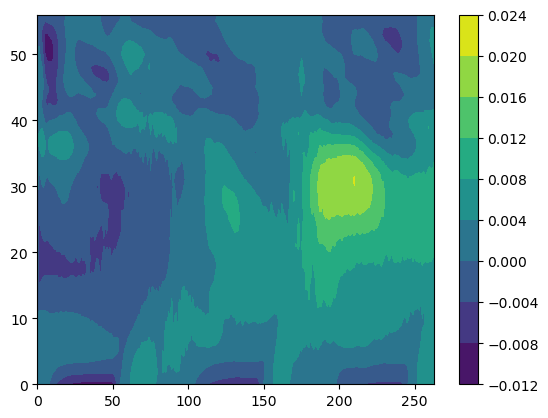

In [125]:
plt.contourf(output.T) 
plt.colorbar() #nice!

In [ ]:
# Notes:
# (1) may need to subset land/water later